In [1]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd
import numpy as np

spec_mjd = 58988.502581
log_scale =  52.33831163468587
data =  {'log_lsun': 8.334207183569124, 't_exp': 17.499252278542855, 'v_start': 5862.778796683932, 'X': 0.550034701281516, 'Z': 0.013024760352725219, 'n': 10.999786025155966, 'v_phot': 7609.0866464947985}

params = data.copy()
params['t_exp'] *= u.day
params['v_start'] *= u.km/u.s
params['v_phot'] *= u.km/u.s

Filters: {'gp', 'up', 'rp', 'ip'}


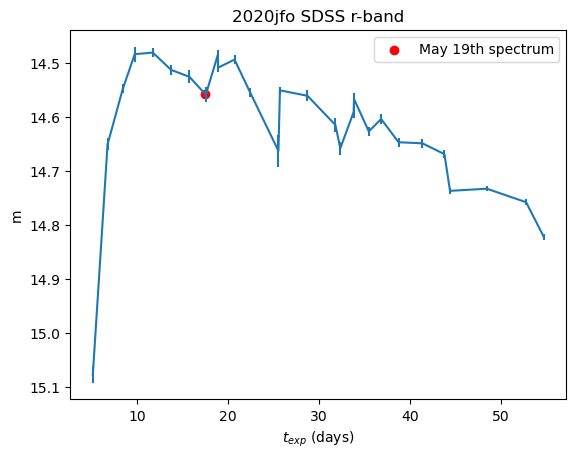

In [6]:
df = pd.read_csv('C:/Users/mikel/Desktop/2020jfo_data.snana.txt', comment='#', sep=r'\s+')
sdss = np.isin(df['FLT'], ['up', 'gp', 'rp', 'ip', 'zp'])
df = df[sdss]
t_exp = 17.5

def get_mags(flt):
    data = df[df['FLT'] == flt]
    t = data['MJD'].values
    m = data['MAG'].values
    m_err = data['MAGERR'].values

    # Zero point should represent the start of the explosion
    t -= spec_mjd - t_exp
    sorted = np.argsort(t)
    t = t[sorted]
    m = m[sorted]
    m_err = m_err[sorted]

    mask = (t > 0) & (t < 60) & (data['DQ'] != 'Bad')
    t = t[mask]
    m = m[mask]
    m_err = m_err[mask]
    return t, m, m_err

print('Filters:', set(df['FLT']))

# Plot all filters
if False:
    for flt in set(df['FLT']):
        t, m, m_err = get_mags(flt)
        if len(t) > 1:
            plt.errorbar(t, m, np.abs(m_err))
            plt.gca().invert_yaxis()
            plt.title(flt)
            plt.axvline(t_exp)
            plt.show()

t, m, m_err = get_mags('rp')
plt.title('2020jfo SDSS r-band')
plt.xlabel(r'$t_{exp}$ (days)')
plt.ylabel('m')
plt.errorbar(t, m, np.abs(m_err))
plt.scatter(t_exp, interp1d(t, m)(t_exp), c='red', label='May 19th spectrum')
plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [7]:
# Print nearest measurement for specific filter
spec_mjd = 58985.4905
flt_df = df[df['FLT'] == 'rp']
near = np.argmin(np.abs(flt_df['MJD'] - spec_mjd))
print('Nearest:', flt_df.iloc[near]['MJD'] - spec_mjd)
print(flt_df.iloc[near])

Nearest: -0.7695000000021537
VARLIST:                  OBS:
MJD                  58984.721
FLT                         rp
FLUXCAL             156604.658
FLUXCALERR            1232.073
MAG                     14.513
MAGERR                   0.009
MAGSYS                     NaN
TELESCOPE     Siding_Spring_1m
INSTRUMENT            Sinistro
DQ                         NaN
Name: 122, dtype: object


In [3]:
# Create data for synthetic light curve
if True:
    from emulator.grid_run.output import set_output_dir, set_folder_name
    from emulator.grid_run.lc import light_curve

    set_output_dir('/mnt/c/Users/mikel/Desktop/')
    set_folder_name('2020jfo_lc')
    light_curve(params, t_list=t, t_min=15, t_max=20, threads=4, config_path='/home/mikel/GitHub/iip-emulator/emulator/sandbox/lightcurve/config.yml')

/home/mikel/GitHub/tardis/tardis/__init__.py:17: UserWarning: Astropy is already imported externally. Astropy should be imported after TARDIS.
  warnings.warn(


Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

Initializing tabulator and plotly panel extensions for widgets to work


Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]
Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]
/home/mikel/GitHub/tardis/tardis/transport/montecarlo/montecarlo_main_loop.py:146: NumbaTypeSafetyWarning:

unsafe cast from uint64 to int64. Precision may be lost.

The formal integral implementation was not specified. Please run with config option numba or cuda.Defaulting to numba implementation.
The number of interpolate_shells was not specified. The value was set to 80.
Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]
Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]
The formal integral implementation was not specified. Please run with config option numba or cuda.Defaulting to numba implementation.
The number of interpolate_shells was not specified. The value was set to 80.
Zeta_data missing - replaced with 1s. Mi

In [6]:
import importlib
import emulator.grid_run.lc
importlib.reload(emulator.grid_run.lc)

<module 'emulator.grid_run.lc' from '/home/mikel/GitHub/iip-emulator/emulator/grid_run/lc.py'>

Spectra calibration time offset: 0.03841899999358134
Reference mag: 14.559


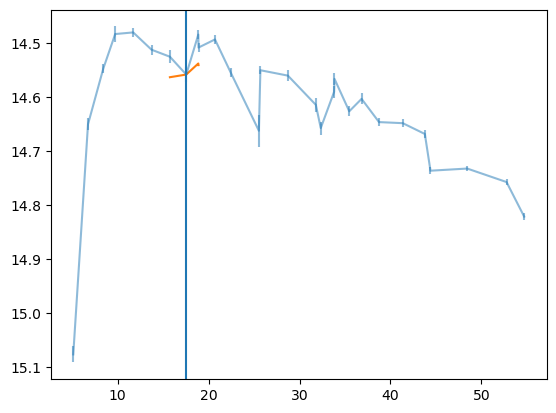

In [ ]:
from emulator.grid_run.lc import photometry, get_sdss_flt

t_exp = params['t_exp'].value
near = np.argmin(np.abs(t - t_exp))
t_0 = t[near]
m_0 = m[near]
print('Spectra calibration time offset:', t_0 - t_exp)
print('Reference mag:', m_0)

sdss_flt = get_sdss_flt()
flt_wave = sdss_flt['R']['wave']
flt_trans = sdss_flt['R']['trans']
t_syn, m_syn = photometry(log_scale, flt_wave, flt_trans, '/mnt/c/Users/mikel/Desktop/2020jfo_lc', t_0=t_0, m_0=m_0)
plt.errorbar(t, m, np.abs(m_err), alpha=0.5)
plt.plot(t_syn, m_syn)
plt.gca().invert_yaxis()
plt.axvline(t_0)
plt.show()